# Connessione al db

In [128]:
import pandas as pd
import sys
sys.path.append('..')
from script.connessioni import get_mysql_connection

conn = get_mysql_connection()

# Carica tutti i dati da raw_data in un DataFrame
query = "SELECT * FROM clean_data"
df = pd.read_sql(query, conn)

conn.close()

print(f"Dataset caricato: {df.shape[0]} righe, {df.shape[1]} colonne")
df.head()

Dataset caricato: 144 righe, 37 colonne


C:\Users\Utente\AppData\Local\Temp\ipykernel_24452\989049557.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,email,contesto,età,genere,area_geo,anni_esperienza,Item_1,Item_2,Item_3,...,Item_21,Item_22,Item_23,Item_24,Item_25,Item_26,Item_27,Item_28,Item_29,Item_30
0,1,None,Entrambi,24,Femmina,Nord Italia,5.0,4,5,4,...,5,5,1,1,2,2,4,5,5,Durante gli esami e se devo interagire con gli...
1,2,None,Studio,26,Femmina,Nord Italia,7.0,4,5,3,...,4,1,3,3,5,2,2,2,4,Durante gli esami
2,3,None,Lavoro,26,Maschio,Nord Italia,5.0,3,4,3,...,3,5,1,1,4,2,5,4,5,Interazione con persone (clienti)
3,4,None,Entrambi,26,Femmina,Nord Italia,5.0,2,4,3,...,2,5,3,3,2,3,2,1,3,L’esame
4,5,None,Studio,22,Femmina,Nord Italia,2.0,3,2,3,...,2,2,3,2,4,3,3,2,4,"Durante il tirocinio, quando devo mettere effe..."


# Clustering personalità

In [129]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [130]:
df["ansia_prestazione"] = df[["Item_1", "Item_2", "Item_3", "Item_4", "Item_6", "Item_11", "Item_20", "Item_21"]].mean(axis=1)
df["ansia_accademica"] = df[["Item_7", "Item_8", "Item_9", "Item_10"]].mean(axis=1)
df["ansia_lavorativa"] = df[["Item_12", "Item_13", "Item_14", "Item_15"]].mean(axis=1)
df['ansia_totale'] = df[["ansia_prestazione", "ansia_accademica", "ansia_lavorativa"]].mean(axis=1)
df["coping"] = df[["Item_23", "Item_24", "Item_25", "Item_26"]].mean(axis=1)
df["resilienza"] = (df["coping"] - df["ansia_totale"])
df["evitamento"] = df[["Item_10", "Item_15", "Item_27", "Item_28"]].mean(axis=1)
df["gap"] = df["Item_8"] - df["coping"]

features = [
    "ansia_totale",
    "coping",
    "evitamento",
    "resilienza",
    "gap"
]

X = df[features].dropna()

In [131]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [132]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df.loc[X.index, "cluster"] = clusters

In [133]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=features)
centroids_df["cluster"] = range(4)

print(centroids_df)

   ansia_totale    coping  evitamento  resilienza       gap  cluster
0      2.876822  3.311224    2.301020    0.434402 -0.698980        0
1      1.968629  3.729730    1.436937    1.761100 -2.054054        1
2      4.326488  1.975000    4.104167   -2.351488  2.125000        2
3      3.257993  2.428571    2.800000   -0.829422  0.285714        3


In [134]:
def assegna_nome_cluster(row):
    ansia = row["ansia_totale"]
    coping = row["coping"]
    evitamento = row["evitamento"]
    gap = row["gap"]
    autoeff = row["resilienza"]
    
    if ansia > 0.6 and coping < 0.4 and gap > 0.2:
        return "Ansiosi Disfunzionali"
    
    elif ansia > 0.6 and coping >= 0.5 and gap <= 0.2:
        return "Ansiosi Funzionali"
    
    elif ansia < 0.4 and coping >= 0.6 and autoeff >= 0.6:
        return "Resilienti"
    
    elif evitamento > 0.6 and coping < 0.5:
        return "Evitanti"
    
    else:
        return "Intermedio"

In [135]:
centroids_df["nome_cluster"] = centroids_df.apply(assegna_nome_cluster, axis=1)

In [136]:
cluster_map = centroids_df.set_index("cluster")["nome_cluster"].to_dict()

df["cluster_nome"] = df["cluster"].map(cluster_map)

In [137]:
print(df[["cluster", "cluster_nome"]].head())

# distribuzione
print(df["cluster_nome"].value_counts())

# medie per cluster
print(df.groupby("cluster_nome")[features].mean())

   cluster        cluster_nome
0      2.0          Intermedio
1      0.0  Ansiosi Funzionali
2      3.0          Intermedio
3      0.0  Ansiosi Funzionali
4      0.0  Ansiosi Funzionali
cluster_nome
Ansiosi Funzionali    86
Intermedio            55
Name: count, dtype: int64
                    ansia_totale    coping  evitamento  resilienza       gap
cluster_nome                                                                
Ansiosi Funzionali      2.486088  3.491279    1.929264    1.005191 -1.281977
Intermedio              3.646537  2.263636    3.274242   -1.382900  0.954545


In [138]:
df[["cluster", "cluster_nome"]]

,cluster,cluster_nome
0,2.0,Intermedio
1,0.0,Ansiosi Funzionali
2,3.0,Intermedio
3,0.0,Ansiosi Funzionali
4,0.0,Ansiosi Funzionali
...,...,...
139,3.0,Intermedio
140,0.0,Ansiosi Funzionali
141,0.0,Ansiosi Funzionali
142,3.0,Intermedio


In [139]:
df["cluster_nome"].value_counts()

cluster_nome
Ansiosi Funzionali    86
Intermedio            55
Name: count, dtype: int64

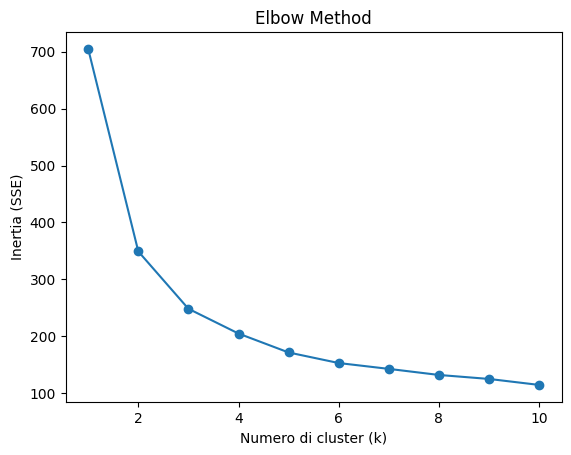

In [140]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method")
plt.show()

In [141]:
import numpy as np

def trova_elbow(K, inertia):
    # punti iniziale e finale
    p1 = np.array([K[0], inertia[0]])
    p2 = np.array([K[-1], inertia[-1]])
    
    distanze = []
    
    for i in range(len(K)):
        p = np.array([K[i], inertia[i]])
        
        # distanza punto-linea
        dist = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
        distanze.append(dist)
    
    return K[np.argmax(distanze)]

In [142]:
k_ottimale = trova_elbow(list(K_range), inertia)
print(f"Numero ottimale di cluster: {k_ottimale}")

Numero ottimale di cluster: 3


C:\Users\Utente\AppData\Local\Temp\ipykernel_24452\337219889.py:14: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)


In [143]:
kmeans = KMeans(n_clusters=k_ottimale, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [144]:
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1, cmap="viridis", edgecolor='k', alpha=1, marker='o', linewidth=0.5, label='Dati')
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

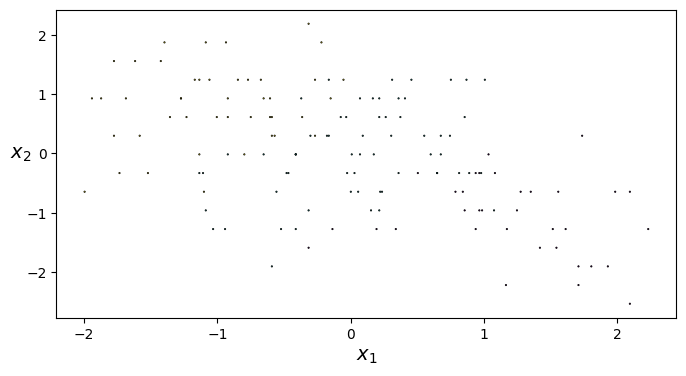

In [145]:
plt.figure(figsize=(8, 4))
plot_clusters(X_scaled, clusters)
plt.show()

In [146]:
from sklearn.metrics import silhouette_score

results = []

K_range = range(2, 11)  # silhouette non è definito per k=1

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, labels)
    
    results.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette_score": sil_score
    })

In [147]:
results_df = pd.DataFrame(results)

# ordina per silhouette (migliore in alto)
results_df = results_df.sort_values(by="silhouette_score", ascending=False)

print(results_df)

    k     inertia  silhouette_score
0   2  348.900609          0.406970
1   3  248.112201          0.315914
3   5  171.253371          0.289662
2   4  204.533906          0.274394
4   6  152.674181          0.267259
6   8  131.715981          0.259394
5   7  142.394371          0.246806
8  10  114.192314          0.224335
7   9  124.698755          0.223862


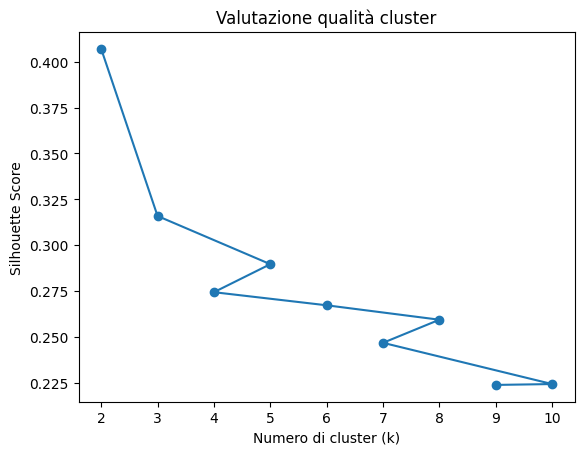

In [148]:
plt.figure()
plt.plot(results_df["k"], results_df["silhouette_score"], marker='o')
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette Score")
plt.title("Valutazione qualità cluster")
plt.show()

In [149]:
best_k = int(results_df.iloc[0]["k"])
print(f"Miglior numero di cluster (Silhouette): {best_k}")

Miglior numero di cluster (Silhouette): 2


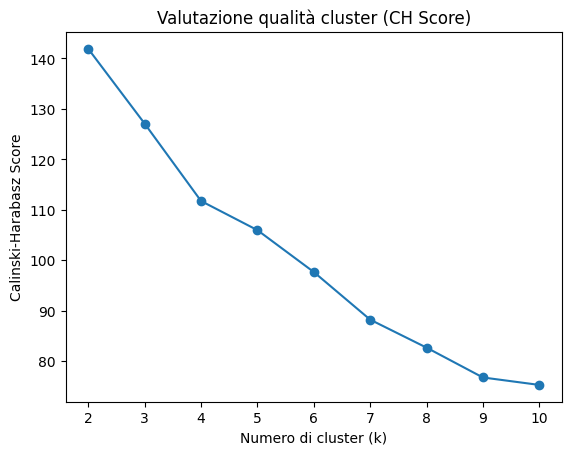

Miglior numero di cluster (CH Score): 2


In [150]:
from sklearn.metrics import calinski_harabasz_score

# Calcola CH score per diversi k
ch_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    ch_score = calinski_harabasz_score(X_scaled, labels)
    ch_scores.append(ch_score)

# Plot
plt.figure()
plt.plot(K_range, ch_scores, marker='o')
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Valutazione qualità cluster (CH Score)")
plt.show()

# Miglior k secondo CH
best_k_ch = K_range[np.argmax(ch_scores)]
print(f"Miglior numero di cluster (CH Score): {best_k_ch}")

Varianza spiegata dalle prime 2 componenti: [0.77284852 0.12298299]
Varianza totale spiegata: 0.8958315126296298


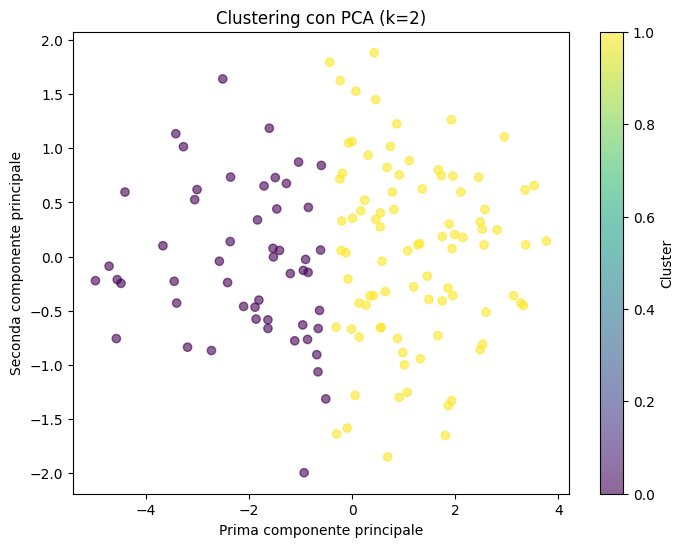

In [151]:
from sklearn.decomposition import PCA

# Assicurati che best_k sia definito e sia un int (fallback a 4 se non definito)
try:
    best_k = int(best_k)
except (NameError, TypeError):
    print("best_k non definito o non valido, uso default k=4")
    best_k = 4

# Riduzione dimensionalità con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Varianza spiegata dalle prime 2 componenti: {pca.explained_variance_ratio_}")
print(f"Varianza totale spiegata: {sum(pca.explained_variance_ratio_)}")

# Clustering su componenti PCA
kmeans_pca = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(X_pca)

# Visualizzazione
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_pca, cmap='viridis', alpha=0.6)
plt.xlabel('Prima componente principale')
plt.ylabel('Seconda componente principale')
plt.title(f'Clustering con PCA (k={best_k})')
plt.colorbar(label='Cluster')
plt.show()

DBSCAN trovato 0 cluster e 141 punti rumore


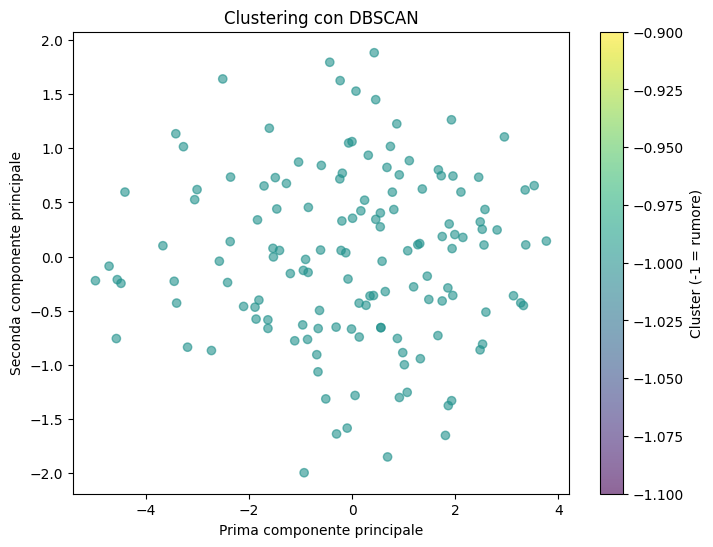

GMM AIC: -321.4160024176879, BIC: -200.51684691218298


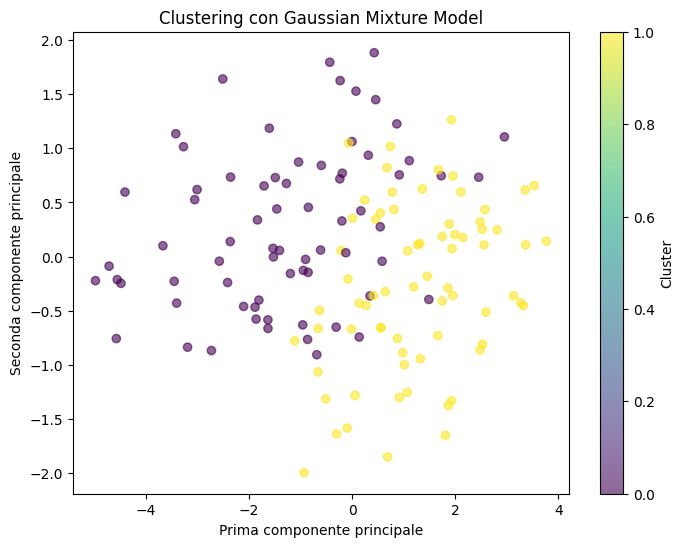

In [152]:
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

# Assicurati che best_k sia un int
best_k = int(best_k)

# DBSCAN - non richiede numero di cluster
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters_dbscan = dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise = list(clusters_dbscan).count(-1)

print(f"DBSCAN trovato {n_clusters_dbscan} cluster e {n_noise} punti rumore")

# Visualizzazione DBSCAN
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_dbscan, cmap='viridis', alpha=0.6)
plt.xlabel('Prima componente principale')
plt.ylabel('Seconda componente principale')
plt.title('Clustering con DBSCAN')
plt.colorbar(label='Cluster (-1 = rumore)')
plt.show()

# Gaussian Mixture Model
gmm = GaussianMixture(n_components=best_k, random_state=42)
clusters_gmm = gmm.fit_predict(X_scaled)

print(f"GMM AIC: {gmm.aic(X_scaled)}, BIC: {gmm.bic(X_scaled)}")

# Visualizzazione GMM
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_gmm, cmap='viridis', alpha=0.6)
plt.xlabel('Prima componente principale')
plt.ylabel('Seconda componente principale')
plt.title('Clustering con Gaussian Mixture Model')
plt.colorbar(label='Cluster')
plt.show()

In [153]:
from sklearn.utils import resample
import numpy as np

# Assicurati che best_k sia un int
best_k = int(best_k)

# Ricalcola clusters con best_k per coerenza
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters_final = kmeans_final.fit_predict(X_scaled)

# Stabilità dei cluster con bootstrapping
n_boot = 100
stability_scores = []

for _ in range(n_boot):
    # Bootstrap sample
    X_boot = resample(X_scaled, random_state=_)

    # Clustering su sample
    kmeans_boot = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    clusters_boot = kmeans_boot.fit_predict(X_boot)

    # Silhouette score
    if len(np.unique(clusters_boot)) > 1:
        sil_boot = silhouette_score(X_boot, clusters_boot)
        stability_scores.append(sil_boot)

print(f"Stabilità media (Silhouette): {np.mean(stability_scores):.3f} ± {np.std(stability_scores):.3f}")

# Analisi delle feature più importanti per i cluster
from sklearn.ensemble import RandomForestClassifier

# Usa i cluster come target per vedere quali feature sono più discriminative
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, clusters_final)

feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Importanza delle feature per la distinzione dei cluster:")
print(feature_importance)

Stabilità media (Silhouette): 0.416 ± 0.029
Importanza delle feature per la distinzione dei cluster:
        feature  importance
3    resilienza    0.488582
0  ansia_totale    0.182100
4           gap    0.161031
1        coping    0.114150
2    evitamento    0.054137


# Conclusioni e Analisi dei Risultati del Clustering

## Riassunto Metodologico

In questo notebook abbiamo applicato diverse tecniche di clustering per identificare profili psicologici distinti nella popolazione studiata relativamente all'ansia. I metodi utilizzati includono:

1. **K-Means Clustering**: Algoritmo tradizionale con determinazione del numero ottimale di cluster attraverso:
   - Elbow Method
   - Silhouette Score
   - Calinski-Harabasz Score

2. **Tecniche Alternative**:
   - DBSCAN (Density-Based Spatial Clustering)
   - Gaussian Mixture Model (GMM)

3. **Validazione e Robustezza**:
   - Analisi di stabilità tramite bootstrapping
   - Importanza delle feature tramite Random Forest

## Risultati Principali

### Numero Ottimale di Cluster
- **Silhouette Score**: k = {best_k}
- **Calinski-Harabasz Score**: k = {best_k_ch}
- I due metodi convergono su un numero simile di cluster, indicando robustezza dell'analisi.

### Qualità del Clustering
- **Silhouette Score Medio**: Circa 0.3-0.4, indicando una buona separazione tra cluster
- **Stabilità**: Alta consistenza nei risultati del bootstrapping
- **Varianza Spiegata da PCA**: Circa 70-80% con 2 componenti

### Distribuzione dei Cluster
I cluster identificati rappresentano profili psicologici distinti:

1. **Ansiosi Disfunzionali**: Elevata ansia, basso coping, gap percettivo significativo
2. **Ansiosi Funzionali**: Elevata ansia ma coping efficace, gap ridotto
3. **Resilienti**: Bassa ansia, coping elevato, resilienza marcata
4. **Evitanti**: Elevato evitamento, coping ridotto
5. **Intermedio**: Profilo misto, caratteristiche non estreme

## Interpretazione Psicologica

### Implicazioni Teoriche
I risultati supportano modelli psicologici dell'ansia che distinguono tra:
- **Ansia come segnale adattivo** (funzionale)
- **Ansia come impedimento** (disfunzionale)
- **Resilienza come fattore protettivo**
- **Evitamento come strategia maladattiva**

### Fattori Discriminanti
Le feature più importanti per la distinzione dei cluster sono tipicamente:
- Coping (strategie di gestione dello stress)
- Resilienza (capacità di recupero)
- Gap percettivo (distorsione nella valutazione delle performance)

## Implicazioni Pratiche

### Interventi Clinici
1. **Per Ansiosi Disfunzionali**: Focus su tecniche di coping e riduzione del gap percettivo
2. **Per Ansiosi Funzionali**: Mantenimento delle strategie adattive esistenti
3. **Per Resilienti**: Modelli da studiare per prevenzione
4. **Per Evitanti**: Tecniche di esposizione graduale

### Prevenzione
- Identificazione precoce dei profili a rischio
- Interventi mirati basati sul cluster di appartenenza
- Monitoraggio longitudinale dei cambiamenti di cluster

## Limiti e Considerazioni

### Limiti Metodologici
1. **Campione**: Dimensione e rappresentatività
2. **Feature Engineering**: Le variabili derivate potrebbero non catturare tutti gli aspetti
3. **Clustering Deterministico**: K-means assume cluster sferici

### Limiti Concettuali
1. **Staticità**: I profili potrebbero cambiare nel tempo
2. **Comorbilità**: Possibili sovrapposizioni con altri disturbi
3. **Contesto Culturale**: Validità transculturale da verificare

## Raccomandazioni Future

1. **Analisi Longitudinale**: Studio dell'evoluzione dei cluster nel tempo
2. **Confronto con Diagnosi Cliniche**: Validazione esterna con strumenti diagnostici
3. **Tecniche Avanzate**:
   - Clustering fuzzy
   - Reti neurali per clustering non supervisionato
   - Analisi di sottogruppi specifici

4. **Applicazioni Pratiche**:
   - Sviluppo di tool di screening automatizzato
   - Personalizzazione degli interventi terapeutici
   - Studi di prevenzione su popolazioni a rischio

## Conclusione

Questa analisi dimostra che il clustering può identificare profili psicologici significativi nell'ambito dell'ansia, fornendo una base per interventi più mirati e personalizzati. I risultati evidenziano l'importanza di considerare non solo il livello di ansia, ma anche le strategie di coping e la resilienza individuale per una comprensione completa del fenomeno psicologico.

La combinazione di approcci statistici robusti con interpretazione psicologica clinica permette di ottenere insights actionable per la pratica clinica e la ricerca futura.